## Step 0 - My standard plot config + import header

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
optimal_figsize_i = 3.5
optimal_figsize_j = 3.5 * ((5**0.5 - 1) / 2)
plt.rcParams["figure.figsize"] = (optimal_figsize_i, optimal_figsize_j)
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

In [2]:
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from scipy.stats import hmean, gmean
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from res import *

combined_mask : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_mask.parquet]
PROJECT */6 COLUMNS
ESTIMATED ROWS: 134519709
combined_atlas : has schema Schema({'face': String, 'i': UInt32, 'j': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x': Float32, 'positions_y': Float32, 'positions_z': Float32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_atlas.parquet]
PROJECT */8 COLUMNS
ESTIMATED ROWS: 402653184
mask_atlas_combined : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x'

## Step 1 - Load the database (Lazy loading is essential)

These all have many more rows than a compute can handel as seen below in the schema and metadata breakdown so lazy operations is very important.

In [3]:
# An example
mask_atlas_combined.filter(pl.col("row_id") == 2).collect()

lod_level,lod_code,face,i,j,row_id,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z
u8,str,str,u32,u32,u32,u8,f32,f32,f32,f32
0,"""""","""posx""",0,4984,2,20,0.003334,0.034584,-0.159367,-0.159384
0,"""""","""posx""",0,4985,2,36,0.006146,0.034627,-0.159368,-0.15939
0,"""""","""posx""",0,5001,2,193,0.033531,0.035251,-0.159395,-0.159416
0,"""""","""posx""",0,5021,2,222,0.038427,0.036024,-0.159347,-0.159371
0,"""""","""posx""",0,5033,2,154,0.026552,0.036472,-0.159287,-0.159307
…,…,…,…,…,…,…,…,…,…,…
0,"""""","""posx""",59,5022,2,83,0.014471,0.036189,-0.159921,-0.157631
0,"""""","""posx""",59,5026,2,55,0.009546,0.036346,-0.159905,-0.157615
0,"""""","""posx""",61,4993,2,99,0.017054,0.03512,-0.160193,-0.157826


In [4]:
number_of_pixels_grouped_by_lod_level = mask_atlas_combined.group_by("row_id") \
    .agg(pl.col("lod_level").first(), pl.len().alias("number_of_pixels")) \
    .group_by("lod_level").agg(
        # pl.col("number_of_pixels").min().alias("min_number_of_pixels"),
        # pl.col("number_of_pixels").max().alias("min_number_of_pixels"),
        # pl.col("number_of_pixels").mean().alias("mean_number_of_pixels"),
        # pl.col("number_of_pixels").std().alias("std_number_of_pixels")
        pl.col("number_of_pixels"),
    ).sort(pl.col("lod_level")).collect()

In [5]:
number_of_pixels_grouped_by_lod_level_list = [
    numb_pixels.to_numpy() for numb_pixels in number_of_pixels_grouped_by_lod_level["number_of_pixels"]
]

[]

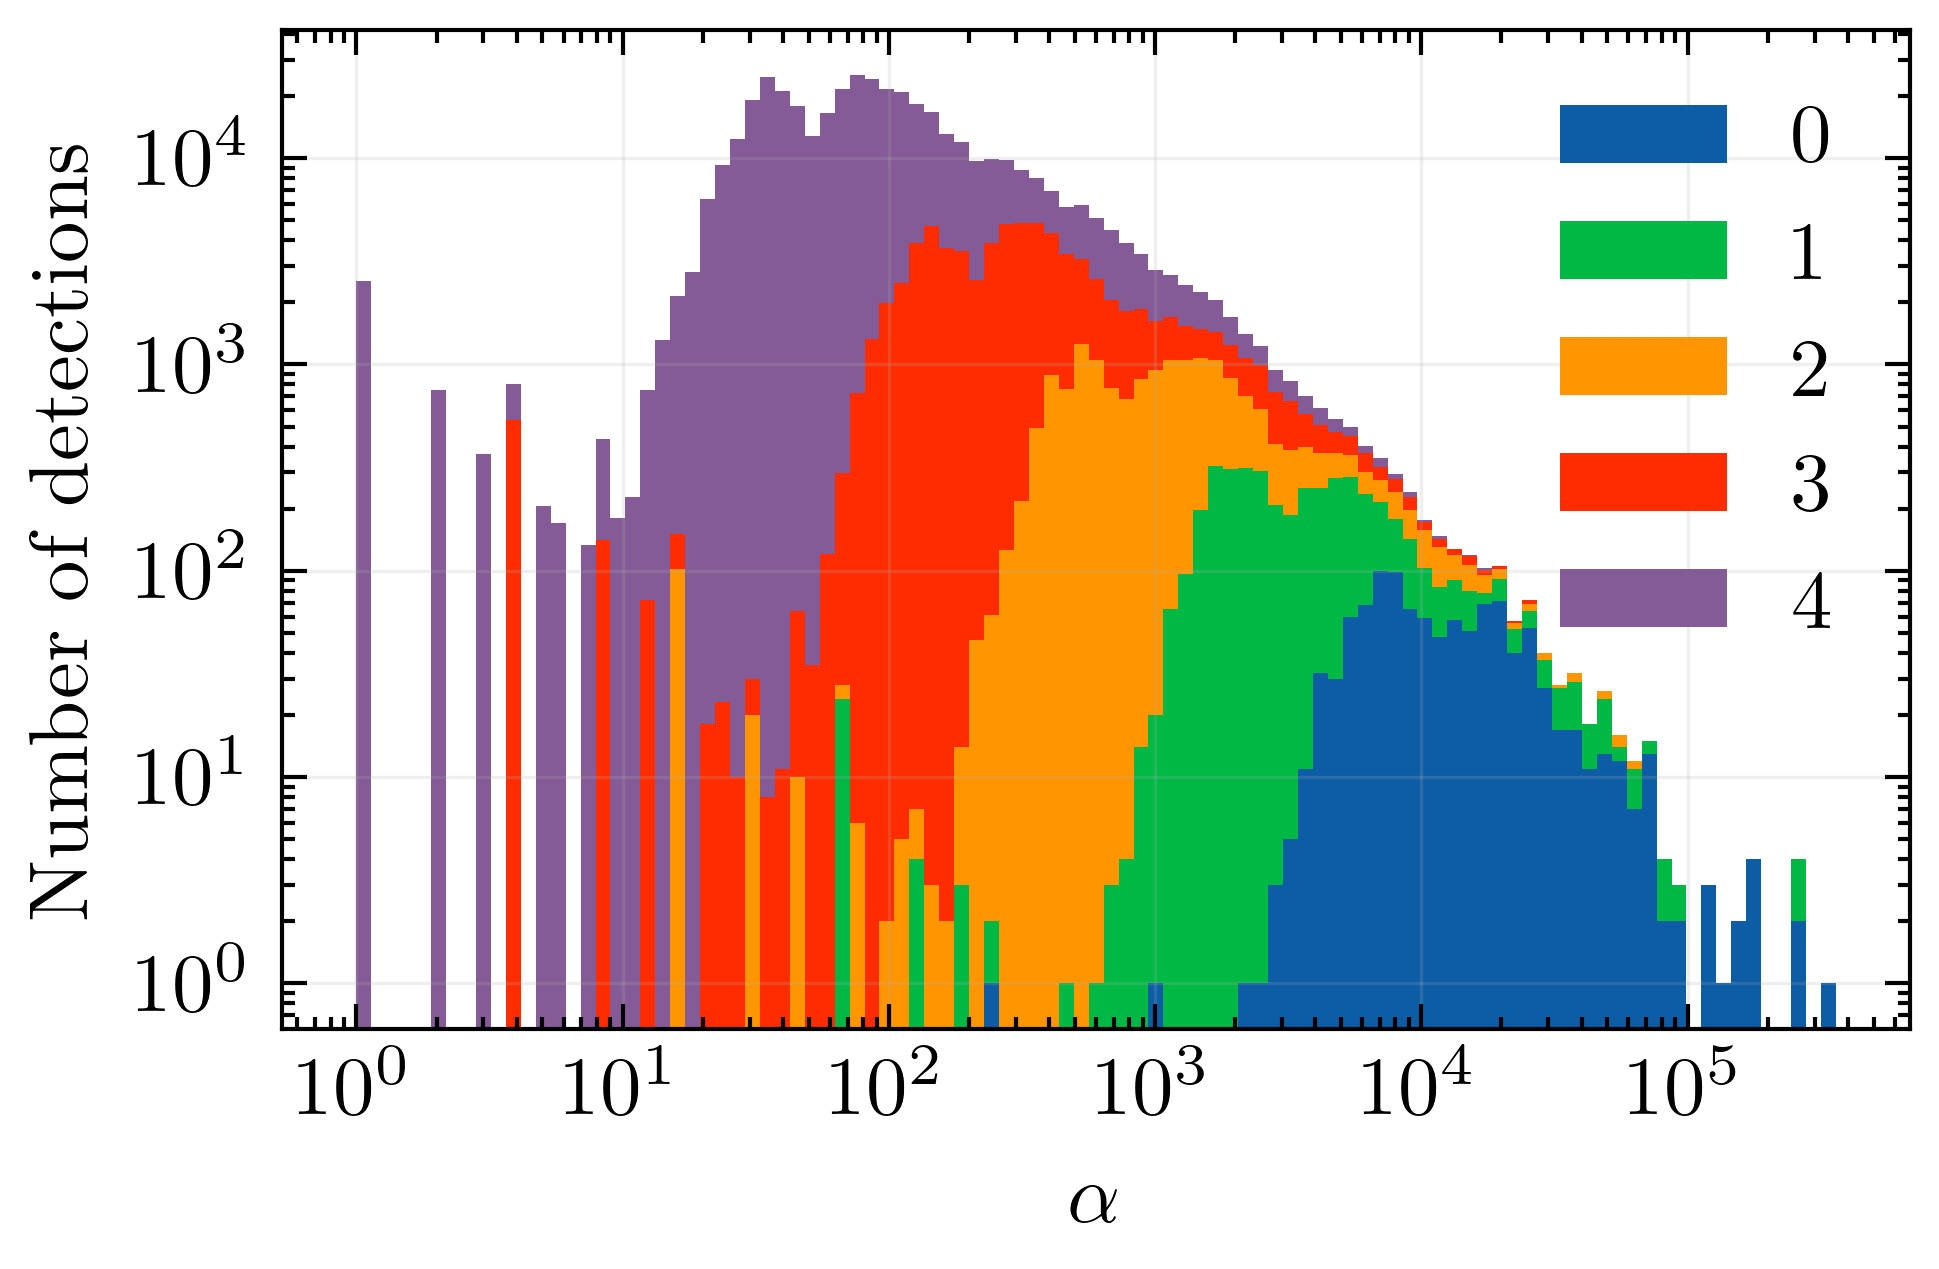

In [6]:
min_number_of_pixels = min([np.min(i) for i in number_of_pixels_grouped_by_lod_level_list])
max_number_of_pixels = max([np.max(i) for i in number_of_pixels_grouped_by_lod_level_list])
bins = np.geomspace(min_number_of_pixels, max_number_of_pixels, 100)

plt.hist(number_of_pixels_grouped_by_lod_level_list, bins, stacked=True,
         label = [f"{i}" for i in number_of_pixels_grouped_by_lod_level["lod_level"]])

plt.xlabel(r"$\alpha$")
plt.ylabel("Number of detections")

plt.xscale("log")
plt.yscale("log")
plt.grid(which='major', linestyle='-', linewidth=0.4, alpha=0.2)
plt.legend()
plt.savefig("total_detections_lod_level_stack.png")
plt.plot()

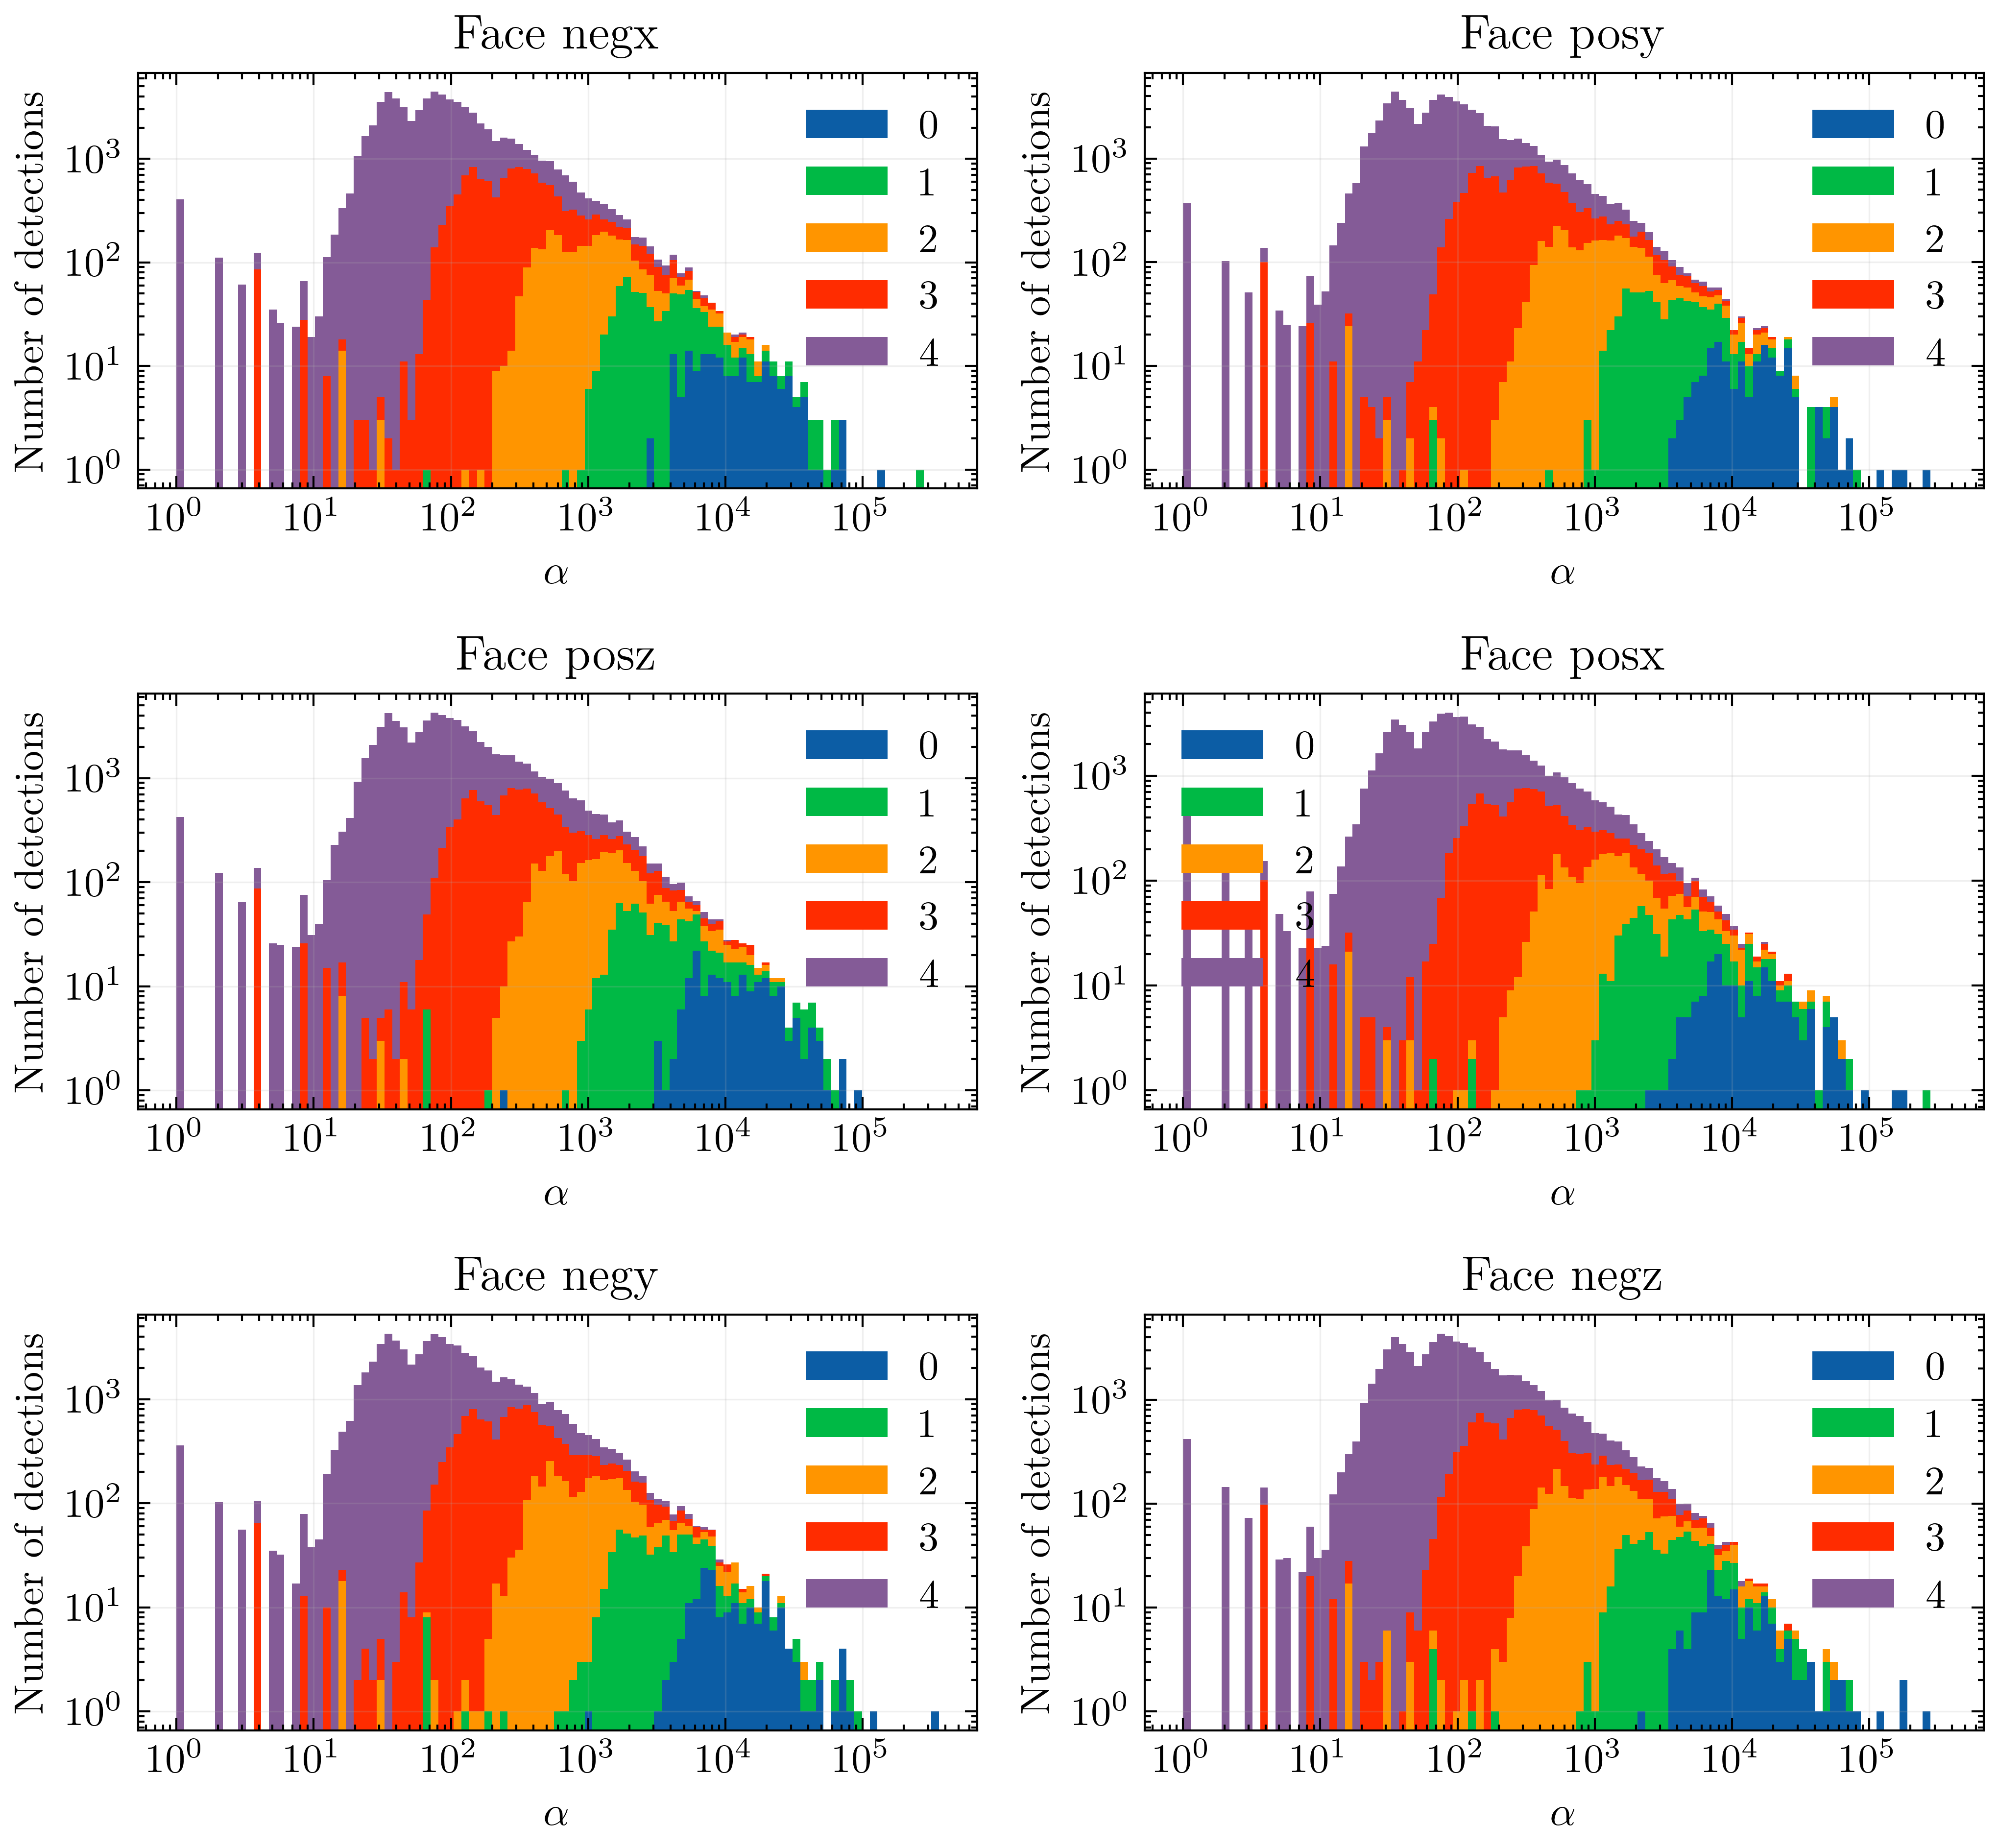

In [7]:
import matplotlib.pyplot as plt

# Create 4x4 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(2*optimal_figsize_i, 3*optimal_figsize_j))
axes = axes.flatten()

for i, face in enumerate(mask_atlas_combined.group_by("face").agg().collect()["face"]):
    ax = axes[i]

    number_of_pixels_grouped_by_lod_level = mask_atlas_combined \
        .filter(pl.col("face") == face) \
        .group_by("row_id") \
        .agg(pl.col("lod_level").first(), pl.len().alias("number_of_pixels")) \
        .group_by("lod_level").agg(
            pl.col("number_of_pixels"),
        ).sort(pl.col("lod_level")).collect()
    
    number_of_pixels_grouped_by_lod_level_list = [
        numb_pixels.to_numpy() for numb_pixels in number_of_pixels_grouped_by_lod_level["number_of_pixels"]
    ]
        
    ax.hist(
        number_of_pixels_grouped_by_lod_level_list,
        bins=bins,
        stacked=True,
        label=[f"{lod}" 
               for lod in number_of_pixels_grouped_by_lod_level["lod_level"]]
    )
    
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Number of detections")
    ax.set_xscale("log")
    ax.set_yscale("log")
    plt.tight_layout()
    ax.set_title(f"Face {face}")
    ax.grid(which='major', linestyle='-', linewidth=0.4, alpha=0.2)
    ax.legend()
    
plt.savefig("total_detections_lod_level_stack_per_face.png")
plt.show()

In [ ]:
df = mask_atlas_combined.group_by("row_id").agg(pl.col("lod_level").first(), pl.col("lod_code").first()).filter(pl.col("lod_level") <= 3).collect()


In [ ]:
from scipy.stats import skew
number_of_detections_per_tile = df.group_by("lod_code").agg(pl.len().alias("number_of_detections"))["number_of_detections"].to_numpy()
print(f"Mean detections per tile {number_of_detections_per_tile.mean():.0f} with standard deviation {number_of_detections_per_tile.std():.0f}")
print(f"Coefficient of variation is {100 * number_of_detections_per_tile.std() / number_of_detections_per_tile.mean():.3f}")
print(f"Skewness {skew(number_of_detections_per_tile):.1f}")

Mean detections per tile 900 with standard deviation 55
Coefficient of variation is 6.076
Skewness -0.1


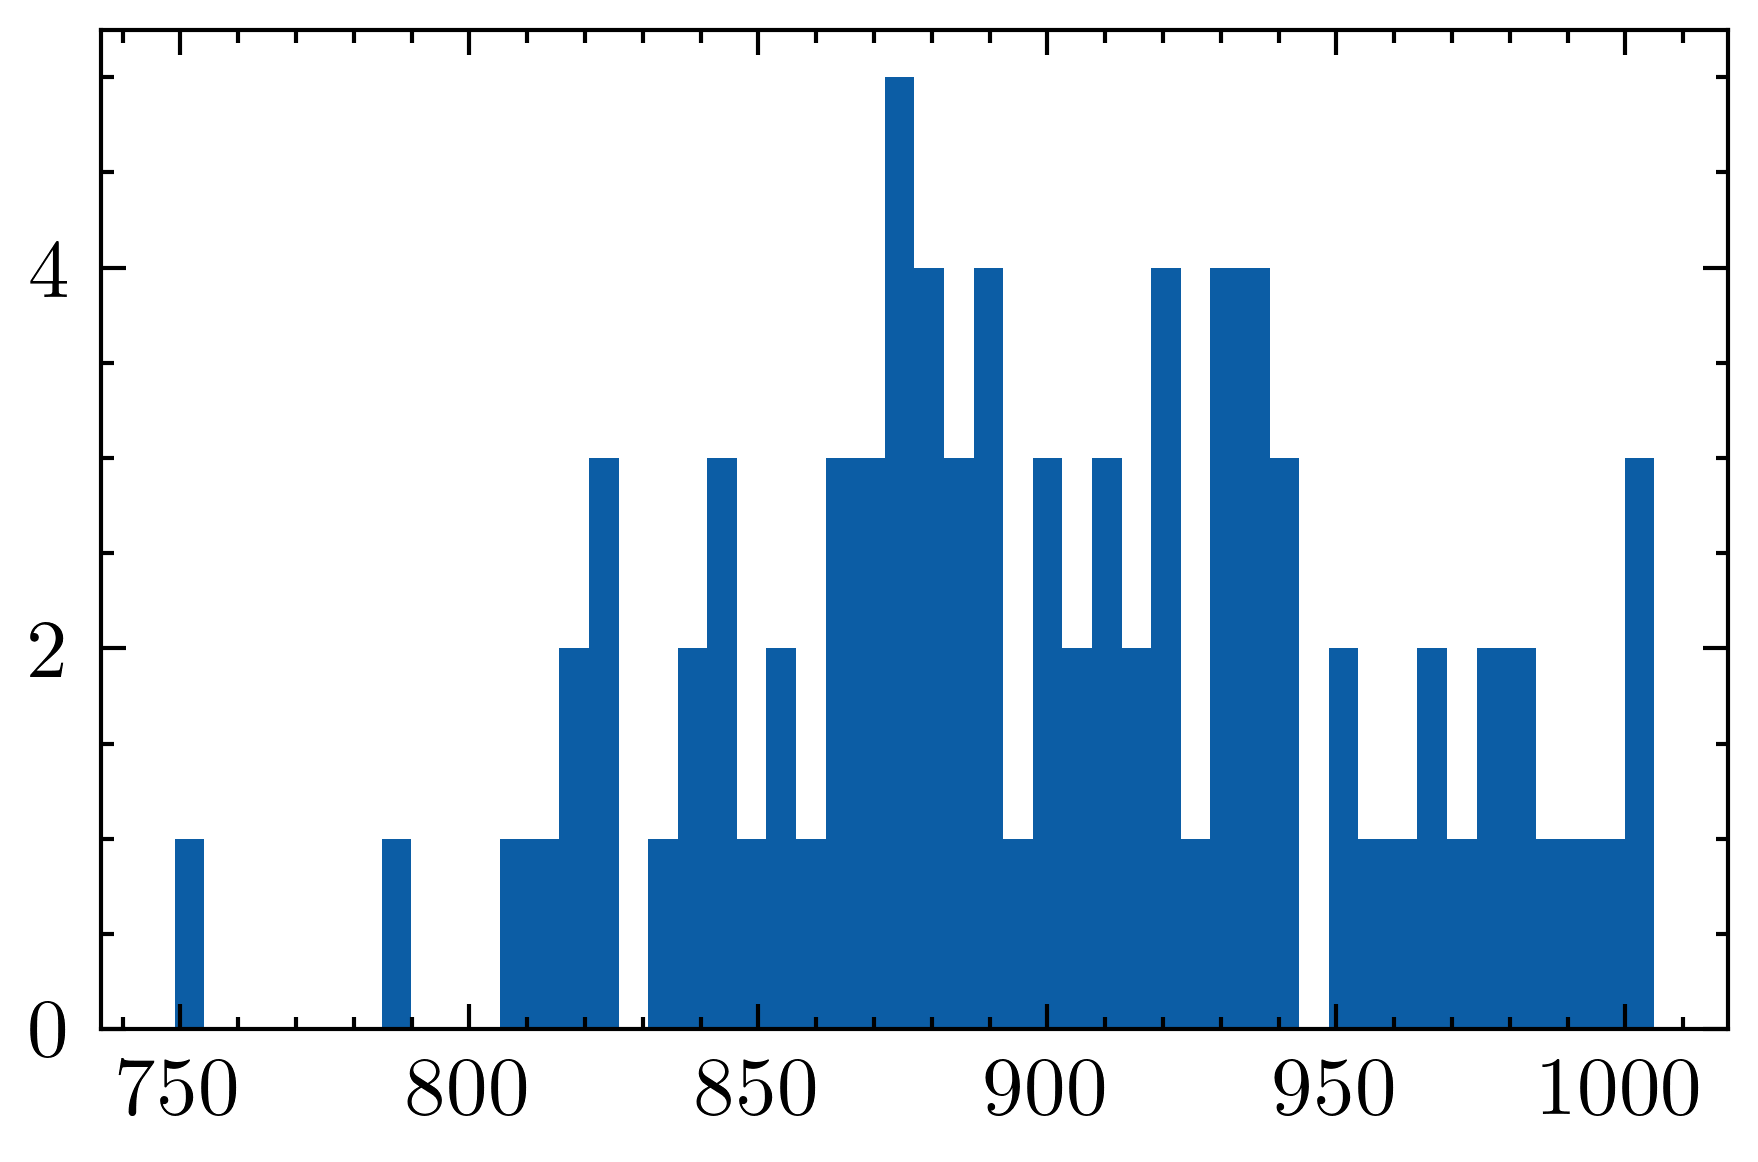

In [ ]:
plt.hist(number_of_detections_per_tile, 50)
plt.show()